In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [2]:
df=pd.read_csv("C:\\Users\\mohd abdul khaleq b\\Downloads\\heart_disease_data.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [4]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

In [5]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

In [6]:
df.shape

(303, 14)

In [7]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [8]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [10]:
df['target'].value_counts()


target
1    165
0    138
Name: count, dtype: int64

In [11]:
#  1--> Defective Heart
#  0--> Healthy Heart

In [43]:
x=df[['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal']]
y=df['target']

<Axes: xlabel='age', ylabel='Count'>

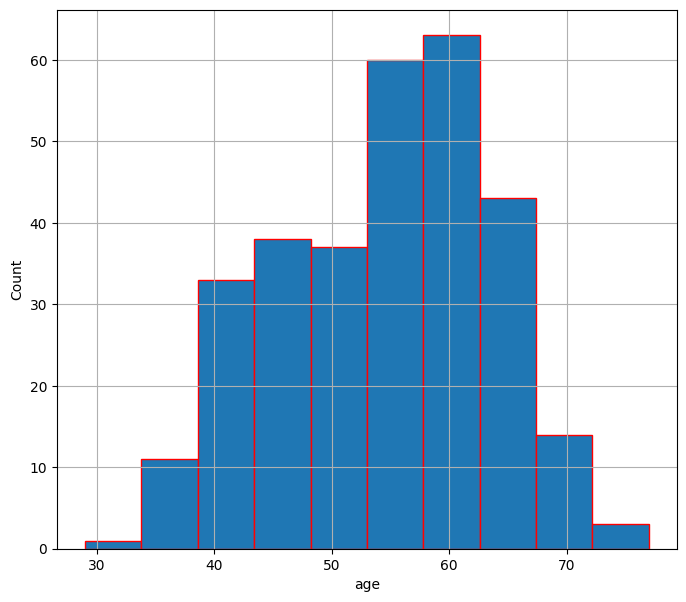

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,7))
plt.xlabel('age')
plt.ylabel('Count')
df['age'].hist(edgecolor='red')

In [26]:
df.groupby(['age'], as_index=False)['target'].sum().sort_values(by='target', ascending=False)

,age,target
20,54,10
17,51,9
18,52,9
7,41,9
10,44,8
8,42,7
24,58,7
23,57,7
19,53,6
30,64,6


In [25]:
df['sex'].value_counts()


sex
1    207
0     96
Name: count, dtype: int64

<Axes: xlabel='sex', ylabel='Count'>

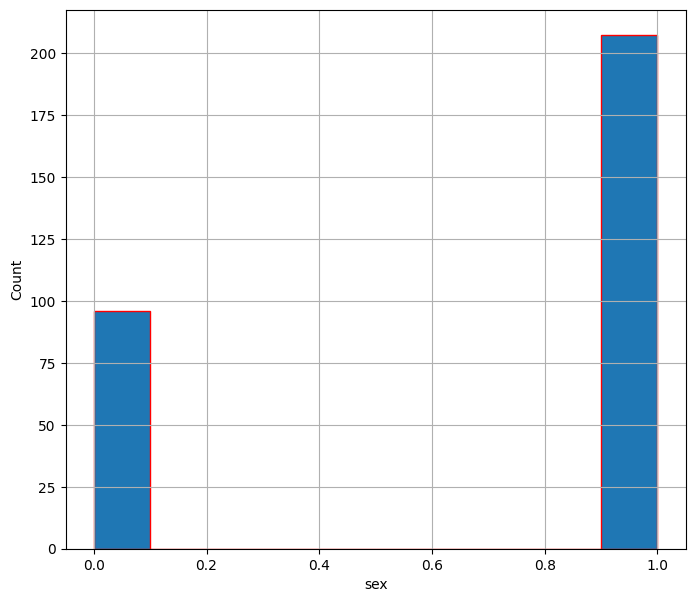

In [14]:
plt.figure(figsize=(8,7))
plt.xlabel('sex')
plt.ylabel('Count')
df['sex'].hist(edgecolor='red')

In [28]:
# Count number of heart disease cases for each sex
sex_heart_counts = df.groupby('sex')['target'].sum()

print(sex_heart_counts)


sex
0    72
1    93
Name: target, dtype: int64


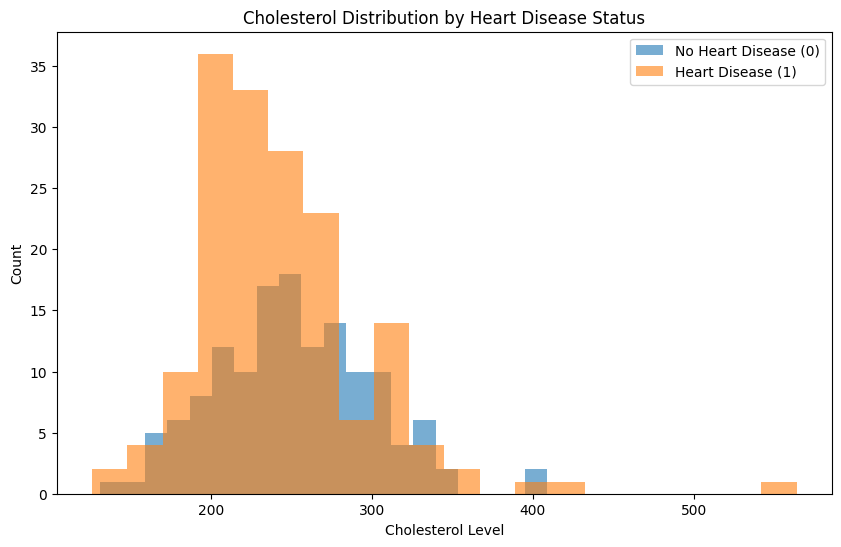

In [32]:
import matplotlib.pyplot as plt

# Split data into two groups
heart_yes = df[df['target'] == 1]['chol']
heart_no  = df[df['target'] == 0]['chol']

plt.figure(figsize=(10,6))

plt.hist(heart_no, bins=20, alpha=0.6, label='No Heart Disease (0)')
plt.hist(heart_yes, bins=20, alpha=0.6, label='Heart Disease (1)')

plt.xlabel('Cholesterol Level')
plt.ylabel('Count')
plt.title('Cholesterol Distribution by Heart Disease Status')
plt.legend()
plt.show()


In [53]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2, random_state=42)

In [57]:
print(x.shape,x_train.shape,x_test.shape) #Distribution 80:20

(303, 13) (242, 13) (61, 13)


In [59]:
lr=LogisticRegression()

In [61]:
lr.fit(x_train,y_train)

C:\Users\mohd abdul khaleq b\ansel\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [63]:
y_pred=lr.predict(x_test)

In [65]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.86      0.88        29
           1       0.88      0.91      0.89        32

    accuracy                           0.89        61
   macro avg       0.89      0.88      0.88        61
weighted avg       0.89      0.89      0.89        61



In [69]:
y_t=lr.predict(x_train)

In [71]:
print(classification_report(y_t,y_train))

              precision    recall  f1-score   support

           0       0.77      0.91      0.84        92
           1       0.94      0.83      0.88       150

    accuracy                           0.86       242
   macro avg       0.86      0.87      0.86       242
weighted avg       0.88      0.86      0.87       242



**Input Data**

In [84]:
input_data=(63,1,3,145,233,1,0,150,0,2.3,0,0,1)

npa=np.array(input_data)

npr=npa.reshape(1,-1)

prediction= lr.predict(npr)

print(prediction)

if (prediction[0]==0):
    print("The person does not have a Heart Disease")
else:
    print("The person has a Heart Disease")

[1]
The person has a Heart Disease


C:\Users\mohd abdul khaleq b\ansel\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
